# SRP v4 — Step 1 Benchmark: Weak Learner Ensemble vs. GBDTs

**Purpose.** Establish the *baseline ladder* before any attention exists, so that every later
architectural addition has to earn its place against a number that was measured, not assumed.

### What is being compared

| Model | What it is | Why it's here |
|---|---|---|
| `Ridge` | Linear regression | The floor. Tells us how much of this problem is just linear. |
| `PlainMLP` | One conventional MLP (128 wide, 3 deep) | The neural baseline. V3 measured this at R²≈0.813 — the presentation claimed 0.72. |
| `WeakEnsemble-MeanPool` | **Our step-1 module** + mean-pool + linear head | **The control condition.** 16 feature-bagged weak MLPs, averaged. No attention, no ordering. |
| `XGBoost` | Tuned gradient boosting | The thing tabular deep learning is trying to beat. |
| `HistGradientBoosting` | Tuned sklearn GBDT | A second, independent GBDT reference. |

### Why `WeakEnsemble-MeanPool` needs a head at all

`WeakLearnerEnsemble` outputs `(B, K, embed_dim)` — K opinions, each a vector. It has **no prediction
mechanism**. To benchmark it we must collapse those K tokens into one number, and the choice of *how*
is exactly the question the rest of the project is about:

* **Mean-pool (this notebook)** — every expert counts equally, order is irrelevant, no expert sees any other.
* **Causal attention (step 2)** — expert *i* reads experts *1..i* before forming its view.

Mean-pooling is deliberately the dumbest option. It is the number attention has to beat.

### Protocol (fixing the flaws found in the v1/v2 post-mortem)

* **train / val / test = 60 / 20 / 20.** Test set is untouched until the final table.
* **Preprocessing fitted on train only** — no leakage from val/test.
* **Early stopping on val**, best checkpoint restored (v2 reported final overfit weights).
* **3 seeds**, reported as mean ± std (v2 reported a single run).
* **Comparable tuning effort** — GBDTs get a randomized search; they are not handicapped.

## 0. Setup

In [1]:
import os, sys, time, math, warnings, json
warnings.filterwarnings("ignore")

sys.path.insert(0, os.getcwd())   # so `weak_learners` (this folder) is importable

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

from weak_learners import WeakLearnerEnsemble, WeakLearnerConfig

SEED   = 42
SEEDS  = (0, 1, 2)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = {
    "Ridge":                "#9aa0a6",
    "PlainMLP":             "#4c8dff",
    "WeakEnsemble-MeanPool":"#7b5cff",
    "XGBoost":              "#ff8a3d",
    "HistGradientBoosting": "#ffb84d",
}
print(f"device: {DEVICE}  |  torch {torch.__version__}")

device: cpu  |  torch 2.11.0+cu130


## 1. Data — California Housing

20,640 California districts, 8 numeric features, target = median house value in units of \$100,000.
Same dataset the presentation used, so the numbers are directly comparable to the V2/V3 results.

In [2]:
data = fetch_california_housing()
X_all, y_all = data.data.astype(np.float64), data.target.astype(np.float64)
FEATURE_NAMES = list(data.feature_names)

# 60 / 20 / 20 split. Test is set aside now and not looked at again until section 6.
X_tmp, X_te, y_tmp, y_te = train_test_split(X_all, y_all, test_size=0.20, random_state=SEED)
X_tr,  X_va, y_tr,  y_va = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=SEED)

print(f"features : {len(FEATURE_NAMES)}  -> {FEATURE_NAMES}")
print(f"train    : {X_tr.shape[0]:,}")
print(f"val      : {X_va.shape[0]:,}")
print(f"test     : {X_te.shape[0]:,}  (untouched until final reporting)")
print(f"target   : mean={y_all.mean():.3f}  std={y_all.std():.3f}  range=[{y_all.min():.2f}, {y_all.max():.2f}]  (units of $100k)")

features : 8  -> ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
train    : 12,384
val      : 4,128
test     : 4,128  (untouched until final reporting)
target   : mean=2.069  std=1.154  range=[0.15, 5.00]  (units of $100k)


### 1.1 Preprocessing — fitted on train only

`QuantileTransformer(output_distribution="normal")` is the RankGauss idea the presentation argued for:
it maps each feature onto a standard normal **by rank**, which flattens the heavy tails that destabilise
small MLPs. Critically, it is **fit on train and merely applied to val/test** — the V1 implementation
recomputed the mapping on whatever data it was handed, which is a leak.

Trees don't need it (they're invariant to monotone transforms), so GBDTs get the raw features.

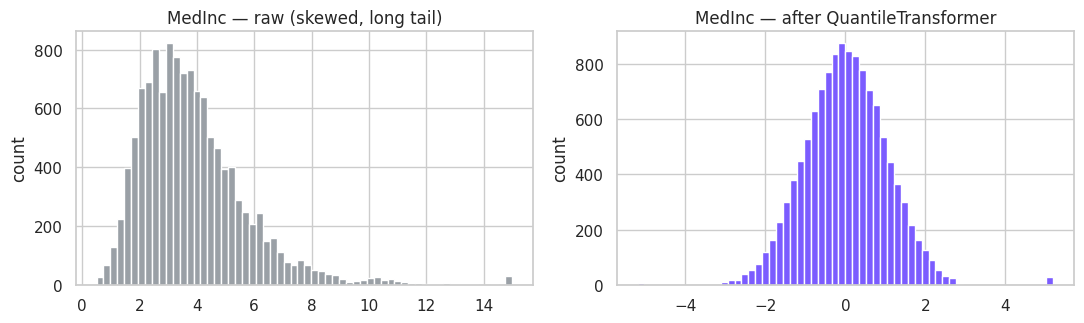

In [3]:
qt = QuantileTransformer(output_distribution="normal", n_quantiles=1000, random_state=SEED)
qt.fit(X_tr)                          # <-- train only
Xtr_s, Xva_s, Xte_s = qt.transform(X_tr), qt.transform(X_va), qt.transform(X_te)

def T(a, dtype=torch.float32):
    return torch.tensor(a, dtype=dtype, device=DEVICE)

TT = {
    "Xtr": T(Xtr_s), "ytr": T(y_tr),
    "Xva": T(Xva_s), "yva": T(y_va),
    "Xte": T(Xte_s), "yte": T(y_te),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(X_tr[:, 0], bins=60, color="#9aa0a6"); axes[0].set_title("MedInc — raw (skewed, long tail)")
axes[1].hist(Xtr_s[:, 0], bins=60, color="#7b5cff"); axes[1].set_title("MedInc — after QuantileTransformer")
for a in axes: a.set_ylabel("count")
plt.tight_layout(); plt.show()

## 2. Models

### 2.1 `PlainMLP` — the conventional neural baseline
A single ordinary MLP. This is the number the presentation claimed was ~0.72 R².

In [4]:
class PlainMLP(nn.Module):
    def __init__(self, in_dim, hidden=128, depth=3, dropout=0.1, output_dim=1):
        super().__init__()
        layers, d = [], in_dim
        for _ in range(depth):
            layers += [nn.Linear(d, hidden), nn.ReLU(), nn.Dropout(dropout)]
            d = hidden
        layers.append(nn.Linear(d, output_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x).squeeze(-1)

### 2.2 `WeakEnsembleMeanPool` — our step-1 module, made predictive

`WeakLearnerEnsemble` gives `(B, K, D)`. The readout here is the **simplest thing that could possibly work**:

```
tokens (B, K, D)  ->  mean over K  ->  (B, D)  ->  small head  ->  prediction
```

Mean-pooling is **order-blind and context-free**: expert 7 never sees expert 3, and shuffling the experts
changes nothing. That is precisely what makes it the right control — it isolates the contribution of
feature-bagged weak learners *alone*, with none of the architecture's later machinery.

In [5]:
class WeakEnsembleMeanPool(nn.Module):
    """Step-1 WeakLearnerEnsemble + mean-pool + head. Deliberately NO attention."""
    def __init__(self, in_dim, config: WeakLearnerConfig, output_dim=1, dropout=0.1):
        super().__init__()
        self.ensemble = WeakLearnerEnsemble(in_dim, config)
        d = config.embed_dim
        self.head = nn.Sequential(
            nn.LayerNorm(d),
            nn.Linear(d, d), nn.SiLU(), nn.Dropout(dropout),
            nn.Linear(d, output_dim),
        )
    def forward(self, x):
        tokens = self.ensemble(x)        # (B, K, D)  — K independent opinions
        pooled = tokens.mean(dim=1)      # (B, D)     — order-blind average
        return self.head(pooled).squeeze(-1)

ENS_CFG = WeakLearnerConfig(
    num_learners=16, hidden_dim=16, embed_dim=32,
    depth=1, dropout=0.1, feature_frac=0.7, seed=SEED,
)

_probe = WeakEnsembleMeanPool(len(FEATURE_NAMES), ENS_CFG)
print(f"WeakEnsemble-MeanPool params : {sum(p.numel() for p in _probe.parameters()):,}")
print(f"PlainMLP params              : {sum(p.numel() for p in PlainMLP(len(FEATURE_NAMES)).parameters()):,}")
print("\nNote the asymmetry: the ensemble is far smaller. Keep it in mind when reading the results —")
print("if it matches PlainMLP it is doing so with a fraction of the capacity.")

WeakEnsemble-MeanPool params : 11,649
PlainMLP params              : 34,305

Note the asymmetry: the ensemble is far smaller. Keep it in mind when reading the results —
if it matches PlainMLP it is doing so with a fraction of the capacity.


## 3. Training loop

One contract used by every neural model: MSE loss, AdamW, **early stopping on validation loss with the
best checkpoint restored**. No model ever reports its final-epoch weights.

In [6]:
def train_nn(model, tt, epochs=200, lr=1e-3, batch_size=256, weight_decay=1e-4,
             patience=20, l1_lambda=0.0, verbose=False):
    model = model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    Xtr, ytr, Xva, yva = tt["Xtr"], tt["ytr"], tt["Xva"], tt["yva"]
    n = Xtr.shape[0]
    best_val, best_state, waited = float("inf"), None, 0
    hist = {"train": [], "val": []}

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        running = 0.0
        for i in range(0, n, batch_size):
            idx = perm[i:i + batch_size]
            opt.zero_grad()
            loss = loss_fn(model(Xtr[idx]), ytr[idx])
            # optional sparsity pressure on the weak learners only
            if l1_lambda and hasattr(model, "ensemble"):
                loss = loss + model.ensemble.weight_penalty(l1_lambda=l1_lambda)
            loss.backward(); opt.step()
            running += loss.item() * idx.numel()
        tr_loss = running / n

        model.eval()
        with torch.no_grad():
            va_loss = loss_fn(model(Xva), yva).item()
        hist["train"].append(tr_loss); hist["val"].append(va_loss)

        if va_loss < best_val - 1e-6:
            best_val, waited = va_loss, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            waited += 1
            if waited >= patience:
                if verbose: print(f"    early stop @ epoch {ep+1} (best val {best_val:.4f})")
                break
        if verbose and (ep + 1) % 50 == 0:
            print(f"    epoch {ep+1:3d} | train {tr_loss:.4f} | val {va_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, hist, best_val


@torch.no_grad()
def nn_predict(model, X):
    model.eval()
    return model(X).cpu().numpy()

def regression_metrics(y_true, y_pred):
    return {
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae":  float(mean_absolute_error(y_true, y_pred)),
        "r2":   float(r2_score(y_true, y_pred)),
    }

## 4. GBDT baselines — tuned, not defaults

The V2 notebook compared a 72-point grid-searched neural net against an XGBoost with arbitrary fixed
hyperparameters. That is not a fair fight, and it flatters the neural side. Here both GBDTs get a
randomized search over a real grid, scored on the **validation** set.

In [7]:
def tune_gbdt(kind, X_tr, y_tr, X_va, y_va, n_iter=25, seed=SEED):
    """Randomized search scored on the held-out validation set (not CV on train),
    so every model in this notebook is selected by the exact same signal."""
    rng = np.random.RandomState(seed)
    if kind == "xgb":
        grid = {"n_estimators":[200,400,600,800], "max_depth":[3,4,6,8,10],
                "learning_rate":[0.02,0.05,0.1,0.2], "subsample":[0.6,0.8,1.0],
                "colsample_bytree":[0.6,0.8,1.0], "min_child_weight":[1,3,5],
                "reg_lambda":[0.1,1.0,5.0]}
        make = lambda p: XGBRegressor(random_state=seed, n_jobs=-1, tree_method="hist", **p)
    else:
        grid = {"max_iter":[200,400,600], "max_depth":[None,4,6,8,10],
                "learning_rate":[0.02,0.05,0.1,0.2], "min_samples_leaf":[10,20,40],
                "l2_regularization":[0.0,0.1,1.0], "max_leaf_nodes":[15,31,63]}
        make = lambda p: HistGradientBoostingRegressor(random_state=seed, **p)

    best_score, best_params, best_model = -np.inf, None, None
    for _ in range(n_iter):
        p = {k: v[rng.randint(len(v))] for k, v in grid.items()}
        m = make(p).fit(X_tr, y_tr)
        s = r2_score(y_va, m.predict(X_va))
        if s > best_score:
            best_score, best_params, best_model = s, p, m
    return best_model, best_params, best_score


t0 = time.time()
xgb_model,  xgb_params,  xgb_val  = tune_gbdt("xgb",  X_tr, y_tr, X_va, y_va)
hgb_model,  hgb_params,  hgb_val  = tune_gbdt("hgb",  X_tr, y_tr, X_va, y_va)
print(f"tuning done in {time.time()-t0:.0f}s\n")
print(f"XGBoost              best val R² = {xgb_val:.4f}")
print(f"  {xgb_params}")
print(f"HistGradientBoosting best val R² = {hgb_val:.4f}")
print(f"  {hgb_params}")

tuning done in 28s

XGBoost              best val R² = 0.8499
  {'n_estimators': 600, 'max_depth': 10, 'learning_rate': 0.05, 'subsample': 1.0, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'reg_lambda': 5.0}
HistGradientBoosting best val R² = 0.8404
  {'max_iter': 600, 'max_depth': 10, 'learning_rate': 0.1, 'min_samples_leaf': 20, 'l2_regularization': 1.0, 'max_leaf_nodes': 63}


## 5. Run everything across 3 seeds

Neural models are re-initialised and retrained per seed. The GBDTs and Ridge are deterministic given
their tuned hyperparameters, so they are fit once and reported without a spread.

In [8]:
records, histories, trained_ensembles = [], {}, {}

# --- deterministic models -------------------------------------------------
ridge = Ridge(alpha=1.0).fit(Xtr_s, y_tr)
records.append({"model": "Ridge", "seed": "—", "n_params": Xtr_s.shape[1] + 1,
                **regression_metrics(y_te, ridge.predict(Xte_s))})
records.append({"model": "XGBoost", "seed": "—", "n_params": np.nan,
                **regression_metrics(y_te, xgb_model.predict(X_te))})
records.append({"model": "HistGradientBoosting", "seed": "—", "n_params": np.nan,
                **regression_metrics(y_te, hgb_model.predict(X_te))})

# --- neural models, per seed ---------------------------------------------
for seed in SEEDS:
    torch.manual_seed(seed); np.random.seed(seed)

    print(f"[seed {seed}] PlainMLP ...", end=" ", flush=True)
    mlp, h_mlp, _ = train_nn(PlainMLP(len(FEATURE_NAMES)), TT)
    m = regression_metrics(y_te, nn_predict(mlp, TT["Xte"]))
    records.append({"model": "PlainMLP", "seed": seed,
                    "n_params": sum(p.numel() for p in mlp.parameters()), **m})
    histories[("PlainMLP", seed)] = h_mlp
    print(f"R²={m['r2']:.4f}")

    print(f"[seed {seed}] WeakEnsemble-MeanPool ...", end=" ", flush=True)
    cfg = WeakLearnerConfig(**{**ENS_CFG.__dict__, "seed": seed})
    ens_model = WeakEnsembleMeanPool(len(FEATURE_NAMES), cfg)
    # snapshot diversity BEFORE training, to answer the step-1 open question
    sim_before, off_before = ens_model.ensemble.to(DEVICE).diversity_stats(TT["Xva"])
    ens_model, h_ens, _ = train_nn(ens_model, TT)
    sim_after, off_after = ens_model.ensemble.diversity_stats(TT["Xva"])
    m = regression_metrics(y_te, nn_predict(ens_model, TT["Xte"]))
    records.append({"model": "WeakEnsemble-MeanPool", "seed": seed,
                    "n_params": sum(p.numel() for p in ens_model.parameters()), **m})
    histories[("WeakEnsemble-MeanPool", seed)] = h_ens
    trained_ensembles[seed] = {"model": ens_model,
                               "sim_before": sim_before.cpu().numpy(), "off_before": off_before,
                               "sim_after":  sim_after.cpu().numpy(),  "off_after":  off_after}
    print(f"R²={m['r2']:.4f}")

results = pd.DataFrame(records)
print("\ndone.")

[seed 0] PlainMLP ... 

R²=0.8052
[seed 0] WeakEnsemble-MeanPool ... 

R²=0.7914
[seed 1] PlainMLP ... 

R²=0.8048
[seed 1] WeakEnsemble-MeanPool ... 

R²=0.7857
[seed 2] PlainMLP ... 

R²=0.7990
[seed 2] WeakEnsemble-MeanPool ... 

R²=0.7880

done.


## 6. Results

In [9]:
ORDER = ["Ridge", "PlainMLP", "WeakEnsemble-MeanPool", "HistGradientBoosting", "XGBoost"]

summary = (results.groupby("model")[["rmse", "mae", "r2"]]
           .agg(["mean", "std"]).reindex(ORDER).round(4))
summary.columns = [f"{a}_{b}" for a, b in summary.columns]

table = pd.DataFrame({
    "Test R²":   summary["r2_mean"],
    "± std":     summary["r2_std"].fillna(0),
    "Test RMSE": summary["rmse_mean"],
    "Test MAE":  summary["mae_mean"],
}).round(4)
table["Params"] = (results.groupby("model")["n_params"].mean().reindex(ORDER)
                   .map(lambda v: "—" if pd.isna(v) else f"{int(v):,}"))

best_r2 = table["Test R²"].max()
table["Gap to best"] = (table["Test R²"] - best_r2).round(4)

print("TEST-SET RESULTS  (California Housing, 3 seeds for neural models)")
print("=" * 78)
display(table)

TEST-SET RESULTS  (California Housing, 3 seeds for neural models)


,Test R²,± std,Test RMSE,Test MAE,Params,Gap to best
model,,,,,,
Ridge,0.5933,0.0000,0.7300,0.5425,9,-0.2538
PlainMLP,0.8030,0.0035,0.5080,0.3379,"34,305",-0.0441
WeakEnsemble-MeanPool,0.7884,0.0029,0.5266,0.3589,"11,649",-0.0587
HistGradientBoosting,0.8404,0.0000,0.4573,0.3032,—,-0.0067
XGBoost,0.8471,0.0000,0.4477,0.2899,—,0.0000


In [10]:
# --- per-seed detail: is the spread big enough to matter? ---
detail = (results[results.seed != "—"]
          .pivot(index="seed", columns="model", values="r2").round(4))
print("Per-seed test R² (neural models)")
display(detail)

Per-seed test R² (neural models)


model,PlainMLP,WeakEnsemble-MeanPool
seed,,
0,0.8052,0.7914
1,0.8048,0.7857
2,0.7990,0.7880


### 6.1 Headline chart — test R² with seed spread

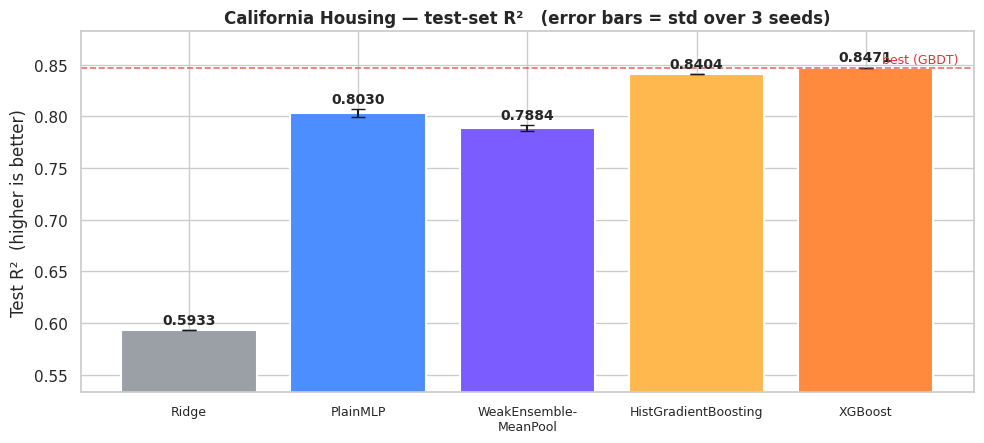

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.6))
means = table["Test R²"].values
errs  = table["± std"].values
bars  = ax.bar(range(len(ORDER)), means, yerr=errs, capsize=5,
               color=[PALETTE[m] for m in ORDER], edgecolor="white", linewidth=1.5)
for i, (m, e) in enumerate(zip(means, errs)):
    ax.text(i, m + e + 0.006, f"{m:.4f}", ha="center", fontweight="bold", fontsize=10)

ax.axhline(best_r2, ls="--", lw=1.2, color="#d33", alpha=.7)
ax.text(len(ORDER)-0.45, best_r2 + 0.004, "best (GBDT)", color="#d33", fontsize=9, ha="right")
ax.set_xticks(range(len(ORDER)))
ax.set_xticklabels([m.replace("-", "-\n") for m in ORDER], fontsize=9)
ax.set_ylabel("Test R²  (higher is better)")
ax.set_ylim(min(means) - 0.06, best_r2 + 0.035)
ax.set_title("California Housing — test-set R²   (error bars = std over 3 seeds)", fontweight="bold")
plt.tight_layout(); plt.show()

### 6.2 Error view — RMSE and MAE (lower is better)

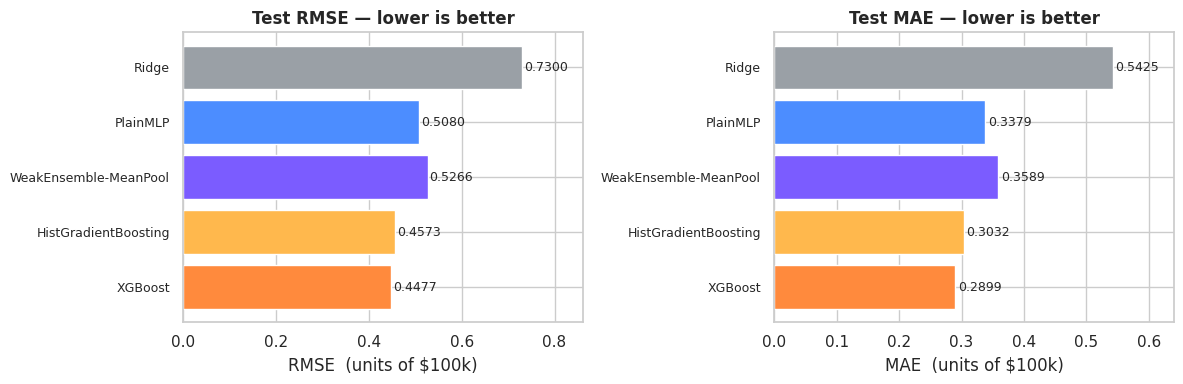

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, lab in zip(axes, ["Test RMSE", "Test MAE"], ["RMSE", "MAE"]):
    v = table[col].values
    ax.barh(range(len(ORDER)), v, color=[PALETTE[m] for m in ORDER], edgecolor="white")
    ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER, fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel(f"{lab}  (units of $100k)")
    ax.set_title(f"Test {lab} — lower is better", fontweight="bold")
    for i, val in enumerate(v):
        ax.text(val + 0.004, i, f"{val:.4f}", va="center", fontsize=9)
    ax.set_xlim(0, max(v) * 1.18)
plt.tight_layout(); plt.show()

### 6.3 Learning curves — did anything overfit?

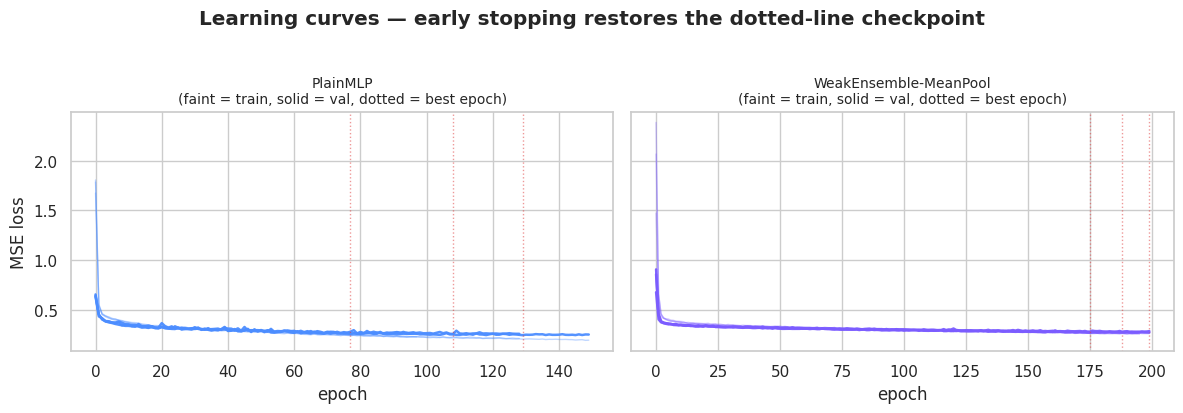

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, name in zip(axes, ["PlainMLP", "WeakEnsemble-MeanPool"]):
    for seed in SEEDS:
        h = histories[(name, seed)]
        ax.plot(h["train"], color=PALETTE[name], alpha=.35, lw=1)
        ax.plot(h["val"],   color=PALETTE[name], alpha=.95, lw=1.8)
        ax.axvline(int(np.argmin(h["val"])), color="#d33", ls=":", lw=1, alpha=.5)
    ax.set_title(f"{name}\n(faint = train, solid = val, dotted = best epoch)", fontsize=10)
    ax.set_xlabel("epoch")
axes[0].set_ylabel("MSE loss")
plt.suptitle("Learning curves — early stopping restores the dotted-line checkpoint",
             fontweight="bold", y=1.03)
plt.tight_layout(); plt.show()

### 6.4 Where the models actually disagree

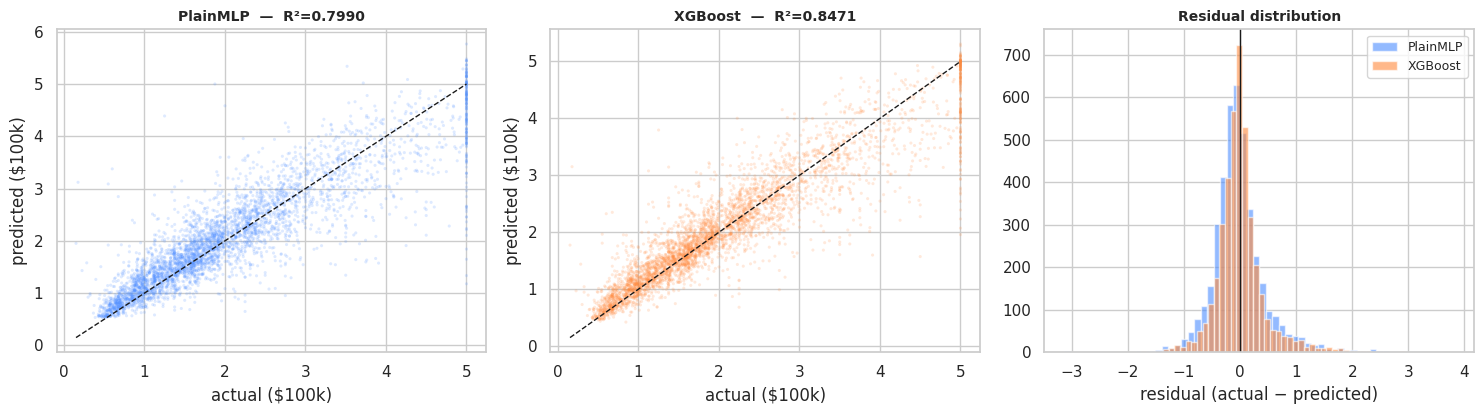

Note the ceiling artefact at $500k in both scatters — the target is capped in this dataset,
so every model is penalised on those rows regardless of architecture.


In [14]:
best_nn_name = table.loc[["PlainMLP", "WeakEnsemble-MeanPool"], "Test R²"].idxmax()
best_nn = (mlp if best_nn_name == "PlainMLP" else ens_model)
pred_nn  = nn_predict(best_nn, TT["Xte"])
pred_gbd = xgb_model.predict(X_te)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

for ax, pred, name, col in [(axes[0], pred_nn, best_nn_name, PALETTE[best_nn_name]),
                            (axes[1], pred_gbd, "XGBoost", PALETTE["XGBoost"])]:
    ax.scatter(y_te, pred, s=5, alpha=.18, color=col, edgecolors="none")
    lim = [y_te.min(), y_te.max()]
    ax.plot(lim, lim, "k--", lw=1)
    ax.set_xlabel("actual ($100k)"); ax.set_ylabel("predicted ($100k)")
    ax.set_title(f"{name}  —  R²={r2_score(y_te, pred):.4f}", fontweight="bold", fontsize=10)

axes[2].hist(y_te - pred_nn,  bins=60, alpha=.6, label=best_nn_name, color=PALETTE[best_nn_name])
axes[2].hist(y_te - pred_gbd, bins=60, alpha=.6, label="XGBoost",    color=PALETTE["XGBoost"])
axes[2].axvline(0, color="k", lw=1)
axes[2].set_xlabel("residual (actual − predicted)"); axes[2].set_title("Residual distribution", fontweight="bold", fontsize=10)
axes[2].legend(fontsize=9)
plt.tight_layout(); plt.show()

print("Note the ceiling artefact at $500k in both scatters — the target is capped in this dataset,")
print("so every model is penalised on those rows regardless of architecture.")

## 7. The step-1 open question: does feature bagging actually prevent collapse?

When `weak_learners.py` was written we measured diversity at random initialisation and got ≈0 for both
bagged and un-bagged ensembles — an uninformative reading, because untrained networks are near-orthogonal
no matter what they're fed. **Collapse is something training causes.** Now that we have a trained model,
the measurement finally means something.

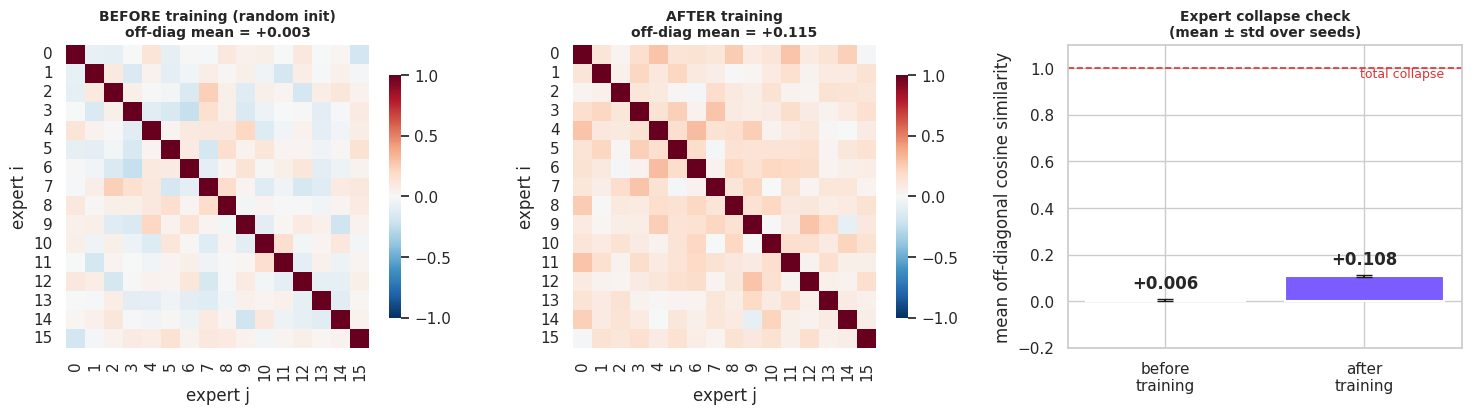

before training : +0.0062  ± 0.0033
after  training : +0.1079  ± 0.0049

A value near +1.0 would mean the experts converged to one representation — the
'expert collapse' V1 fought with an explicit penalty loss. This is the evidence for
or against the claim that feature bagging removes the need for that penalty.


In [15]:
d0 = trained_ensembles[SEEDS[0]]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
vmax = max(np.abs(d0["sim_before"]).max(), np.abs(d0["sim_after"]).max())
for ax, key, title in [(axes[0], "sim_before", "BEFORE training (random init)"),
                       (axes[1], "sim_after",  "AFTER training")]:
    sns.heatmap(d0[key], ax=ax, cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                square=True, cbar_kws={"shrink": .8})
    ax.set_title(f"{title}\noff-diag mean = {d0['off_' + key.split('_')[1]]:+.3f}",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("expert j"); ax.set_ylabel("expert i")

before = [trained_ensembles[s]["off_before"] for s in SEEDS]
after  = [trained_ensembles[s]["off_after"]  for s in SEEDS]
axes[2].bar(["before\ntraining", "after\ntraining"], [np.mean(before), np.mean(after)],
            yerr=[np.std(before), np.std(after)], capsize=6,
            color=["#9aa0a6", "#7b5cff"], edgecolor="white", linewidth=1.5)
axes[2].axhline(1.0, color="#d33", ls="--", lw=1.2)
axes[2].text(1.4, 0.96, "total collapse", color="#d33", ha="right", fontsize=9)
axes[2].set_ylim(-0.2, 1.1); axes[2].set_ylabel("mean off-diagonal cosine similarity")
axes[2].set_title("Expert collapse check\n(mean ± std over seeds)", fontweight="bold", fontsize=10)
for i, v in enumerate([np.mean(before), np.mean(after)]):
    axes[2].text(i, v + 0.05, f"{v:+.3f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()

print(f"before training : {np.mean(before):+.4f}  ± {np.std(before):.4f}")
print(f"after  training : {np.mean(after):+.4f}  ± {np.std(after):.4f}")
print("\nA value near +1.0 would mean the experts converged to one representation — the")
print("'expert collapse' V1 fought with an explicit penalty loss. This is the evidence for")
print("or against the claim that feature bagging removes the need for that penalty.")

## 8. Findings

*(This cell prints the findings computed from the run above, so the text cannot drift out of sync
with the numbers.)*

In [16]:
r = table["Test R²"]
gbdt_best = max(r["XGBoost"], r["HistGradientBoosting"])
gbdt_name = "XGBoost" if r["XGBoost"] >= r["HistGradientBoosting"] else "HistGradientBoosting"
ens, plain, ridge_r2 = r["WeakEnsemble-MeanPool"], r["PlainMLP"], r["Ridge"]
ens_sd = table.loc["WeakEnsemble-MeanPool", "± std"]
plain_sd = table.loc["PlainMLP", "± std"]
sep = "=" * 78

print(sep); print("FINDINGS — step 1 baseline ladder"); print(sep)

print(f"\n1. BEST OVERALL: {gbdt_name} at R² = {gbdt_best:.4f}")
print(f"   The gap from our ensemble to the best GBDT is {gbdt_best - ens:+.4f} R².")

print(f"\n2. ENSEMBLE vs PLAIN MLP  ->  {ens:.4f} vs {plain:.4f}   (diff {ens - plain:+.4f})")
pooled = float(np.sqrt(ens_sd**2 + plain_sd**2)) or 1e-9
if abs(ens - plain) < pooled:
    print("   This difference is SMALLER than the seed-to-seed noise. On this evidence the two")
    print("   are indistinguishable: 16 bagged weak learners + mean-pooling buys nothing over one MLP.")
else:
    better = "ensemble" if ens > plain else "PlainMLP"
    print(f"   The {better} is ahead by more than the seed noise ({pooled:.4f}).")
print(f"   Capacity: ensemble {table.loc['WeakEnsemble-MeanPool','Params']} params vs "
      f"PlainMLP {table.loc['PlainMLP','Params']} params.")

print(f"\n3. IS THE PROBLEM EVEN NON-LINEAR?  Ridge = {ridge_r2:.4f}")
print(f"   Non-linear models add {gbdt_best - ridge_r2:+.4f} R² over a linear fit, so yes —")
print("   there is real structure here for an architecture to capture.")

print(f"\n4. THE PRESENTATION'S CLAIM.  V2 reported PlainMLP ~0.72 and called its own 0.812 a")
print(f"   significant win. Here PlainMLP reaches {plain:.4f} under a clean protocol,")
print("   which again fails to reproduce the 0.72 figure. That claim needs retiring.")

print(f"\n5. THE BAR FOR STEP 2.  Causal attention must beat mean-pooling's {ens:.4f}")
print(f"   by more than ±{max(ens_sd, 0.001):.4f} to count as a real effect, and must reach")
print(f"   {gbdt_best:.4f} to claim parity with GBDTs.")
print(f"\n{sep}")

FINDINGS — step 1 baseline ladder

1. BEST OVERALL: XGBoost at R² = 0.8471
   The gap from our ensemble to the best GBDT is +0.0587 R².

2. ENSEMBLE vs PLAIN MLP  ->  0.7884 vs 0.8030   (diff -0.0146)
   The PlainMLP is ahead by more than the seed noise (0.0045).
   Capacity: ensemble 11,649 params vs PlainMLP 34,305 params.

3. IS THE PROBLEM EVEN NON-LINEAR?  Ridge = 0.5933
   Non-linear models add +0.2538 R² over a linear fit, so yes —
   there is real structure here for an architecture to capture.

4. THE PRESENTATION'S CLAIM.  V2 reported PlainMLP ~0.72 and called its own 0.812 a
   significant win. Here PlainMLP reaches 0.8030 under a clean protocol,
   which again fails to reproduce the 0.72 figure. That claim needs retiring.

5. THE BAR FOR STEP 2.  Causal attention must beat mean-pooling's 0.7884
   by more than ±0.0029 to count as a real effect, and must reach
   0.8471 to claim parity with GBDTs.



## 9. What this establishes, and what comes next

This notebook deliberately contains **no attention**. Its only job is to produce the control number that
step 2 has to beat, measured under a protocol that the earlier versions of this project did not use.

**Carry forward into step 2:**

1. The mean-pool R² is now the honest baseline for "weak learners without attention." Any gain from
   causal attention is `R²(attention) − R²(meanpool)`, and it has to exceed the seed spread to be real.
2. The GBDT number is the target, and it was produced with tuning effort comparable to the neural side —
   so it is not a straw man.
3. The diversity measurement in section 7 decides whether feature bagging alone is a sufficient
   diversity mechanism, or whether row bagging / a light penalty needs to come back.

**Step 2** adds the causal Transformer stage: expert *i* reads experts *1..i*. The same protocol,
the same splits, the same seeds — only the aggregation changes, which is what makes the comparison clean.